# State of Data Brasil — Análise


In [6]:
%idle_timeout 60
%glue_version 5.0
%worker_type G.1X
%number_of_workers 2
%%configure
{
  "--enable-job-insights": "false",
  "--job-language": "python"
}

Welcome to the Glue Interactive Sessions Kernel
For more information on available magic commands, please type %help in any new cell.

Please view our Getting Started page to access the most up-to-date information on the Interactive Sessions kernel: https://docs.aws.amazon.com/glue/latest/dg/interactive-sessions.html
Installed kernel version: 1.0.10 
Current idle_timeout is None minutes.
idle_timeout has been set to 60 minutes.
Setting Glue version to: 5.0
Previous worker type: None
Setting new worker type to: G.1X
Previous number of workers: None
Setting new number of workers to: 2
The following configurations have been updated: {'--enable-job-insights': 'false', '--job-language': 'python'}


In [1]:
import sys
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from awsglue.context import GlueContext
from awsglue.job import Job
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

sc = SparkContext.getOrCreate()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)

spark

Trying to create a Glue session for the kernel.
Session Type: glueetl
Worker Type: G.1X
Number of Workers: 2
Idle Timeout: 60
Session ID: b8537f14-bfac-49dd-863f-4d47b9255e2c
Applying the following default arguments:
--glue_kernel_version 1.0.10
--enable-glue-datacatalog true
--enable-job-insights false
--job-language python
Waiting for session b8537f14-bfac-49dd-863f-4d47b9255e2c to get into ready status...
Session b8537f14-bfac-49dd-863f-4d47b9255e2c has been created.


## Carregar os dados

In [2]:
DATABASE_GOLD = "db_gold"

def carregar_tabela_gold(nome_tabela: str):
    """Lê uma tabela Gold pelo Glue Data Catalog e devolve um Spark DataFrame."""
    dyf = glueContext.create_dynamic_frame.from_catalog(
        database=DATABASE_GOLD,
        table_name=nome_tabela
    )
    return dyf.toDF()

tb_empresa_atual = carregar_tabela_gold("tb_gold_empresa_atual")
tb_ia = carregar_tabela_gold("tb_gold_ia")
tb_pessoa = carregar_tabela_gold("tb_gold_pessoa")
tb_rotina_profissional = carregar_tabela_gold("tb_gold_rotina_profissional")
tb_stack_tecnologico = carregar_tabela_gold("tb_gold_stack_tecnologico")

tb_pessoa.printSchema()

root
 |-- faixa_idade: string (nullable = true)
 |-- faixa_salarial: string (nullable = true)
 |-- idade: string (nullable = true)
 |-- genero: string (nullable = true)
 |-- cor_raca_etnia: string (nullable = true)
 |-- token: string (nullable = true)
 |-- ano_pesquisa: integer (nullable = true)
 |-- data_hora_envio: string (nullable = true)
 |-- pcd: string (nullable = true)
 |-- exp_prof_nao_prejud: boolean (nullable = true)
 |-- exp_prof_prejud: string (nullable = true)
 |-- exp_prof_prejud_cor_raca_etnia: boolean (nullable = true)
 |-- exp_prof_prejud_ident_gen: boolean (nullable = true)
 |-- exp_prof_prejud_pcd: boolean (nullable = true)
 |-- aspectos_prejud: string (nullable = true)
 |-- aspectos_prejud_aprova_em_selecao: boolean (nullable = true)
 |-- aspectos_prejud_atencao_opiniao_ideias: boolean (nullable = true)
 |-- aspectos_prejud_nvl_cobranca_e_stress_trab: boolean (nullable = true)
 |-- aspectos_prejud_oport_progressao_carreira: boolean (nullable = true)
 |-- aspectos_pr

## Qual é o cenário de diversidade de gênero nas carreiras de dados?

In [3]:
##Diversidade de genero

# Contagem bruta por gênero e ano
contagem_genero = tb_pessoa.groupBy("genero", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd"))

# Total de respondentes por ano = todo mundo com token preenchido
total_por_ano = tb_pessoa.filter(F.col("token").isNotNull()) \
    .groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# Join e cálculo do percentual
resultado_pct = contagem_genero.join(total_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_respondentes") * 100, 1))

# Pivot para o formato de tabela (genero x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("genero") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

                 genero  2023  2024  2025
0  Prefiro não informar   0.3   0.3   0.4
1                 Outro   0.2   0.2   0.2
2              Feminino  24.4  23.5  22.0
3             Masculino  75.1  76.1  77.5


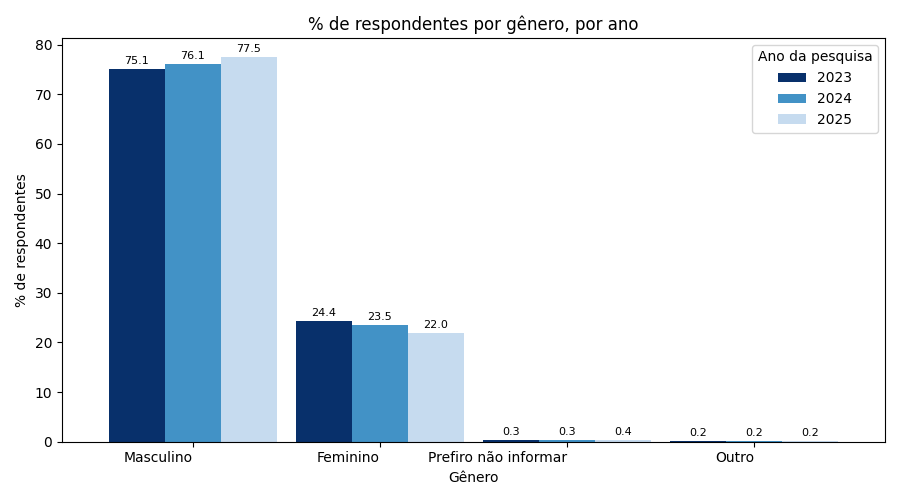

In [4]:
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("genero")
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False)

ax = df_pandas_pct.plot(kind="bar", figsize=(9, 5), color=["#08306b", "#4292c6", "#c6dbef"], width=0.9)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)

plt.title("% de respondentes por gênero, por ano")
plt.ylabel("% de respondentes")
plt.xlabel("Gênero")
plt.xticks(rotation=0, ha="right")
plt.legend(title="Ano da pesquisa", loc="upper right")
plt.tight_layout()
plt.show()
%matplot plt

In [5]:
#Generos que tiveram a experiência no trabalho prejudicada

# Total de pessoas por gênero e ano (esse é o novo denominador: dentro de cada grupo)
total_por_genero_ano = tb_pessoa.groupBy("genero", "ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_no_genero"))

# Contagem de quem respondeu TRUE para prejuízo profissional, por gênero e ano
contagem_true = tb_pessoa.filter(F.col("exp_prof_prejud_ident_gen") == True) \
    .groupBy("genero", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# Join e cálculo do percentual DENTRO de cada grupo de gênero
resultado_pct = total_por_genero_ano.join(contagem_true, on=["genero", "ano_pesquisa"], how="left") \
    .fillna(0, subset=["qtd_true"]) \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_no_genero") * 100, 1))

# Pivot para o formato de tabela (genero x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("genero") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

                 genero  2023  2024  2025
0  Prefiro não informar  37.5  46.7  30.8
1                 Outro  66.7  25.0  71.4
2              Feminino  56.6  63.6  61.9
3             Masculino   1.2   1.4   1.5


In [6]:
# 0. Filtra a base para quem respondeu diferente de "Masculino"
tb_pessoa_filtrado = tb_pessoa.filter(F.col("genero") != "Masculino")

# 1. Despivotar as 9 colunas de aspectos prejudicados (wide -> long)
aspectos_long = tb_pessoa_filtrado.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(9,
        'Quantidade de Vagas', aspectos_prejud_qtd_oport_vagas,
        'Senioridade das vagas x experiência', aspectos_prejud_senioridade_vagas_vs_exp,
        'Aprovação em processos seletivos', aspectos_prejud_aprova_em_selecao,
        'Oportunidade de progessão na carreira', aspectos_prejud_oport_progressao_carreira,
        'Velocidade de progessão na carreira', aspectos_prejud_velocidade_progressao_carreira,
        'Cobrança no trabalho', aspectos_prejud_nvl_cobranca_e_stress_trab,
        'Atenção á opinião e ideias', aspectos_prejud_atencao_opiniao_ideias,
        'Relação com colegas no trabalho', aspectos_prejud_rel_outros_membros_empresa_dentro_trab,
        'Relação com colegas fora do trabalho', aspectos_prejud_rel_outros_membros_empresa_fora_trab
    ) as (aspecto, prejudicado)"""
)

# 2. Total da base filtrada (quem respondeu diferente de Masculino) por ano
total_por_ano_filtrado = tb_pessoa_filtrado.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# 3. Contagem de "true" por aspecto e ano
contagem_true = aspectos_long.filter(F.col("prejudicado") == True) \
    .groupBy("aspecto", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# 4. Join e cálculo do percentual
resultado_pct = contagem_true.join(total_por_ano_filtrado, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

# 5. Pivotar para visualização (aspecto x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("aspecto") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

                                 aspecto  2023  2024  2025
0       Aprovação em processos seletivos  24.7  22.3  20.2
1  Oportunidade de progessão na carreira  32.5  39.1  39.3
2                   Cobrança no trabalho  20.4  21.9  22.9
3   Relação com colegas fora do trabalho  18.0  16.0  17.5
4    Senioridade das vagas x experiência  24.4  27.4  25.9
5        Relação com colegas no trabalho  23.7  22.2  22.9
6    Velocidade de progessão na carreira  36.4  42.4  39.0
7             Atenção á opinião e ideias  39.6  44.4  43.1
8                    Quantidade de Vagas  24.1  25.5  23.3


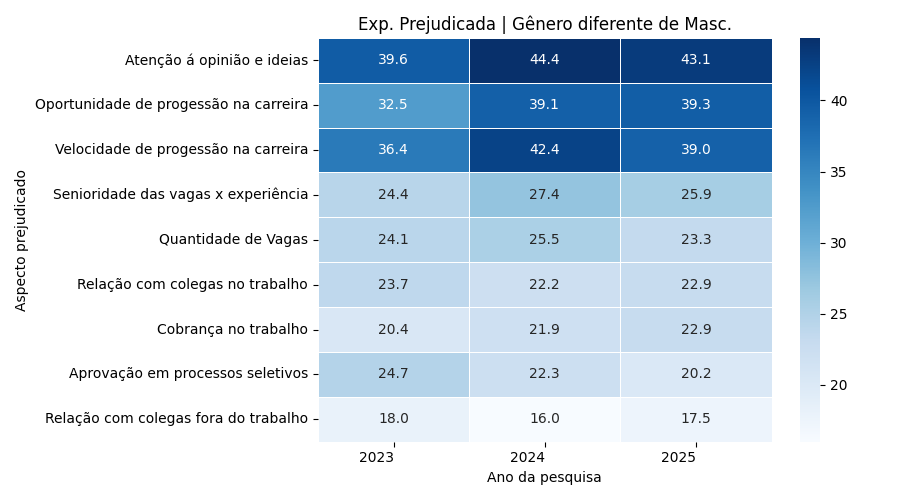

In [7]:
# Preparação dos dados
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("aspecto")
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False)

# Configuração da figura
plt.figure(figsize=(9, 5))

# Criação do Heatmap
ax = sns.heatmap(
    df_pandas_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5
)

# Títulos e rótulos
plt.title("Exp. Prejudicada | Gênero diferente de Masc.")
plt.ylabel("Aspecto prejudicado")
plt.xlabel("Ano da pesquisa")
plt.yticks(rotation=0)
plt.xticks(rotation=0, ha="right")

plt.tight_layout()
plt.show()
%matplot plt

## Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?

In [8]:
regiao = tb_pessoa.groupby("regiao_onde_mora").pivot("ano_pesquisa").count().show(truncate=False)
senioridade = tb_pessoa.groupby("nivel").pivot("ano_pesquisa").count().show(truncate=False)
modelo_trabalho = tb_pessoa.groupby("modelo_de_trabalho_atual").pivot("ano_pesquisa").count().show(truncate=False)
faixa_salario = tb_pessoa.groupby("faixa_salarial").pivot("ano_pesquisa").count().show(truncate=False)

+----------------+----+----+----+
|regiao_onde_mora|2023|2024|2025|
+----------------+----+----+----+
|                |124 |142 |125 |
|Centro-oeste    |344 |332 |231 |
|Sudeste         |3173|3131|2170|
|Sul             |961 |1030|540 |
|Nordeste        |608 |516 |380 |
|Norte           |83  |64  |48  |
+----------------+----+----+----+

+-------------------+----+----+----+
|nivel              |2023|2024|2025|
+-------------------+----+----+----+
|                   |1436|1399|994 |
|Pleno              |1392|1376|775 |
|Júnior             |1046|868 |518 |
|Especialista/Staff+|NULL|NULL|349 |
|Sênior             |1419|1572|858 |
+-------------------+----+----+----+

+--------------------------------------------------------------------------------------------------------------+----+----+----+
|modelo_de_trabalho_atual                                                                                      |2023|2024|2025|
+--------------------------------------------------------------------

#### Regiao e senioridade

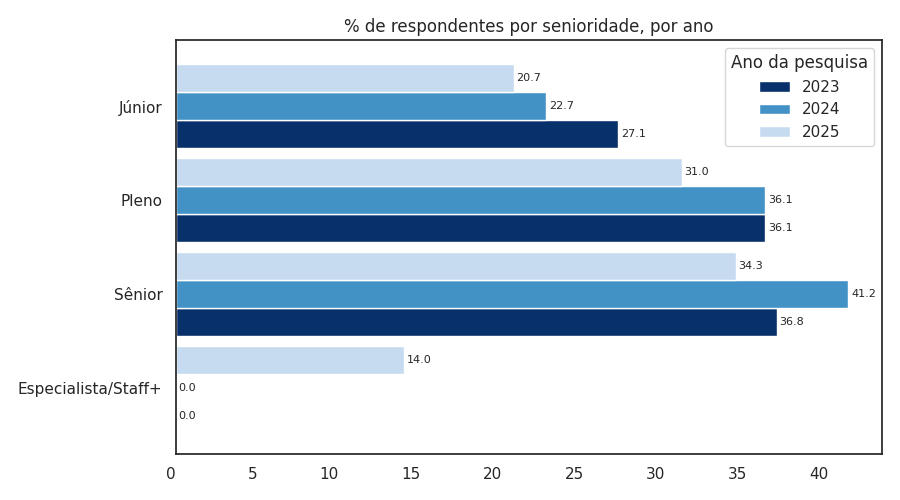

In [52]:
# Nível
tb_nivel_valido = tb_pessoa.filter(
    (F.col("nivel").isNotNull()) &
    (F.trim(F.col("nivel")) != "")
)
total_por_ano_nivel = tb_nivel_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))
contagem_nivel = tb_nivel_valido.groupBy("nivel", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd"))
resultado_pct_nivel = contagem_nivel.join(total_por_ano_nivel, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_respondentes") * 100, 1))
pivot_nivel = resultado_pct_nivel.groupBy("nivel") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

# Ordem fixa por senioridade
ordem_senioridade = ["Especialista/Staff+", "Sênior", "Pleno", "Júnior"]

df_nivel = pivot_nivel.toPandas().set_index("nivel").reindex(ordem_senioridade)

ax = df_nivel.plot(kind="barh", figsize=(9, 5), color=["#08306b", "#4292c6", "#c6dbef"], width=0.9)
for c in ax.containers: ax.bar_label(c, fmt="%.1f", padding=2, fontsize=8)
plt.title("% de respondentes por senioridade, por ano")
plt.ylabel(""); plt.xlabel("")
plt.xticks(rotation=0, ha="right"); plt.legend(title="Ano da pesquisa", loc="upper right")
plt.tight_layout(); plt.show()
%matplot plt

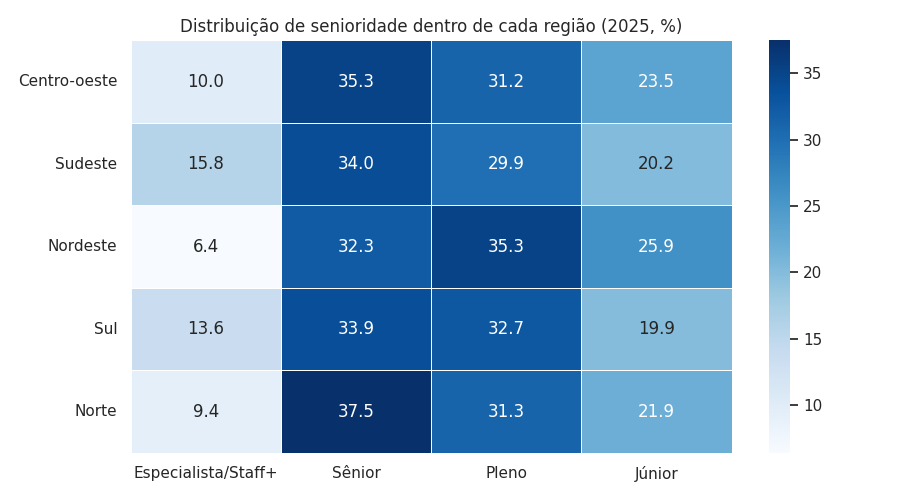

In [53]:
tb_cruzamento_nivel = tb_pessoa.filter(
    (F.col("nivel").isNotNull()) &
    (F.trim(F.col("nivel")) != "") &
    (F.col("regiao_onde_mora").isNotNull()) &
    (F.trim(F.col("regiao_onde_mora")) != "") &
    (F.col("ano_pesquisa") == 2025)
)

contagem_cruzada_nivel = tb_cruzamento_nivel.groupBy("regiao_onde_mora", "nivel") \
    .agg(F.count("token").alias("qtd"))

total_por_regiao_nivel = tb_cruzamento_nivel.groupBy("regiao_onde_mora") \
    .agg(F.countDistinct("token").alias("total_regiao"))

resultado_cruzado_pct_nivel = contagem_cruzada_nivel.join(total_por_regiao_nivel, on="regiao_onde_mora", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_regiao") * 100, 1))

pivot_cruzado_nivel = resultado_cruzado_pct_nivel.groupBy("regiao_onde_mora") \
    .pivot("nivel") \
    .agg(F.first("percentual"))

df_cruzado_nivel = pivot_cruzado_nivel.toPandas().set_index("regiao_onde_mora").fillna(0)

# Ordem fixa por senioridade 
ordem_senioridade = ["Especialista/Staff+", "Sênior", "Pleno", "Júnior"]
df_cruzado_nivel = df_cruzado_nivel.reindex(columns=ordem_senioridade)

plt.figure(figsize=(9, 5))
sns.heatmap(df_cruzado_nivel, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição de senioridade dentro de cada região (2025, %)")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()
%matplot plt

#### Região e Modelo de trabalho

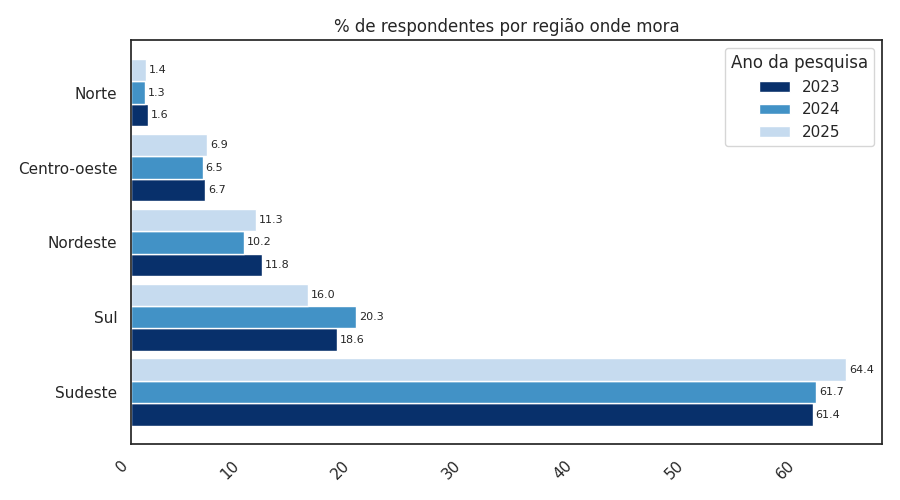

In [54]:
# Região
tb_regiao_valido = tb_pessoa.filter(
    (F.col("regiao_onde_mora").isNotNull()) &
    (F.trim(F.col("regiao_onde_mora")) != "")
)
total_por_ano_regiao = tb_regiao_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))
contagem_regiao = tb_regiao_valido.groupBy("regiao_onde_mora", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd"))
resultado_pct_regiao = contagem_regiao.join(total_por_ano_regiao, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_respondentes") * 100, 1))
pivot_regiao = resultado_pct_regiao.groupBy("regiao_onde_mora") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

df_regiao = pivot_regiao.toPandas().set_index("regiao_onde_mora").sort_values(by="2025", ascending=False)
ax = df_regiao.plot(kind="barh", figsize=(9, 5), color=["#08306b", "#4292c6", "#c6dbef"], width=0.9)
for c in ax.containers: ax.bar_label(c, fmt="%.1f", padding=2, fontsize=8)
plt.title("% de respondentes por região onde mora")
plt.ylabel(""); plt.xlabel("")
plt.xticks(rotation=45, ha="right"); plt.legend(title="Ano da pesquisa", loc="upper right")
plt.tight_layout(); plt.show()
%matplot plt

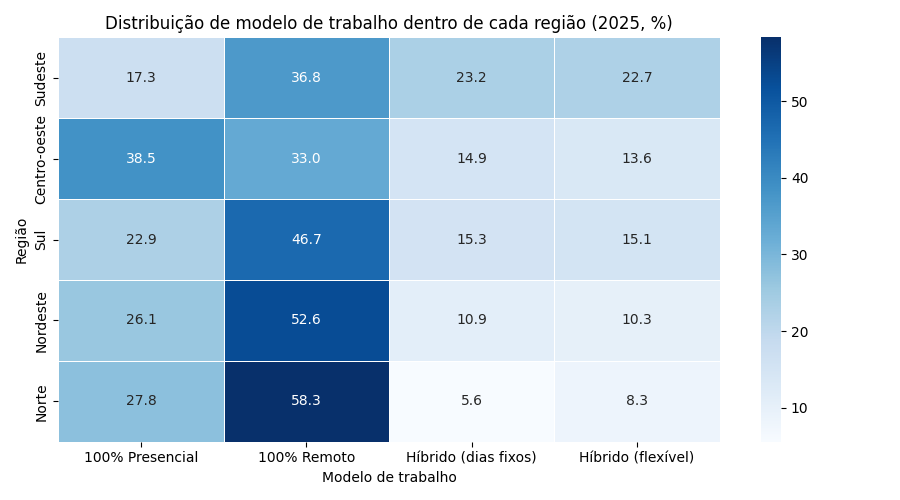

In [20]:
tb_cruzamento = tb_pessoa.filter(
    (F.col("modelo_de_trabalho_atual").isNotNull() & (F.trim(F.col("modelo_de_trabalho_atual")) != "")) &
    (F.col("regiao_onde_mora").isNotNull() & (F.trim(F.col("regiao_onde_mora")) != "")) &
    (F.col("ano_pesquisa") == 2025) &
    (F.col("modelo_de_trabalho_atual") != "Não participei de entrevistas de emprego/processos seletivos nos últimos 6 meses")
)

contagem_cruzada = tb_cruzamento.groupBy("regiao_onde_mora", "modelo_de_trabalho_atual") \
    .agg(F.count("token").alias("qtd"))

total_por_regiao = tb_cruzamento.groupBy("regiao_onde_mora") \
    .agg(F.countDistinct("token").alias("total_regiao"))

resultado_cruzado_pct = contagem_cruzada.join(total_por_regiao, on="regiao_onde_mora", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_regiao") * 100, 1))

pivot_cruzado = resultado_cruzado_pct.groupBy("regiao_onde_mora") \
    .pivot("modelo_de_trabalho_atual") \
    .agg(F.first("percentual"))

df_cruzado = pivot_cruzado.toPandas().set_index("regiao_onde_mora").fillna(0)

# Encurtando os rótulos das colunas
mapa_labels = {
    "Modelo 100% remoto": "100% Remoto",
    "Modelo 100% presencial": "100% Presencial",
    "Modelo híbrido com dias fixos de trabalho presencial": "Híbrido (dias fixos)",
    "Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)": "Híbrido (flexível)",
}
df_cruzado = df_cruzado.rename(columns=mapa_labels)

plt.figure(figsize=(9, 5))
sns.heatmap(df_cruzado, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição de modelo de trabalho dentro de cada região (2025, %)")
plt.ylabel("Região")
plt.xlabel("Modelo de trabalho")
plt.tight_layout()
plt.show()
%matplot plt

## Quais tecnologias apresentam maior adoção entre os profissionais?

### Fonte de dado 

In [17]:
# 1. Despivotar as colunas de fontes de dados (wide -> long)
fontes_long = tb_stack_tecnologico.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(8,
        'dados_relacionais', fontes_de_dados_trabalhadas_dados_relacionais,
        'bancos_nosql', fontes_de_dados_trabalhadas_bancos_nosql,
        'imagens', fontes_de_dados_trabalhadas_imagens,
        'textos_documentos', fontes_de_dados_trabalhadas_textos_documentos,
        'videos', fontes_de_dados_trabalhadas_videos,
        'audios', fontes_de_dados_trabalhadas_audios,
        'planilhas', fontes_de_dados_trabalhadas_planilhas,
        'dados_georeferenciados', fontes_de_dados_trabalhadas_dados_georeferenciados
    ) as (fonte_de_dado, trabalhada)"""
)

# 2. Total de respondentes por ano (base confiável: tb_pessoa)
total_por_ano = tb_pessoa.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# 3. Contagem de "true" por fonte de dado e ano
contagem_true = fontes_long.filter(F.col("trabalhada") == True) \
    .groupBy("fonte_de_dado", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# 4. Join para calcular o percentual
resultado_pct = contagem_true.join(total_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

# 5. Pivotar para visualização (fonte de dado x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("fonte_de_dado") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

            fonte_de_dado  2023  2024  2025
0       dados_relacionais  64.0  64.7  56.2
1       textos_documentos  41.1  40.6  37.9
2               planilhas  64.8  63.1  53.7
3                  videos   2.9   3.3   3.3
4            bancos_nosql  25.8  26.4  23.9
5  dados_georeferenciados  21.5  21.8  18.7
6                  audios   3.0   3.9   4.9
7                 imagens  10.9  12.2  12.1


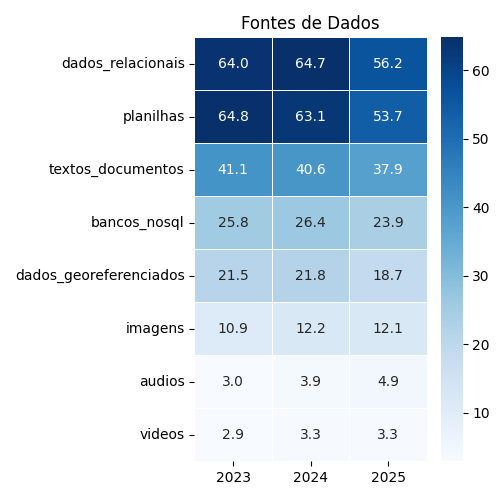

In [18]:
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("fonte_de_dado")

# Ordena do maior para o menor, com base na coluna 2025
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False)

plt.figure(figsize=(5, 5))

sns.heatmap(
    df_pandas_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5
)

plt.title("Fontes de Dados")
plt.ylabel("")
plt.xlabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
%matplot plt

### Banco de dados

In [21]:
# 1. Despivotar as colunas de bancos de dados trabalhados (wide -> long)
bancos_dados_long = tb_stack_tecnologico.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(33,
        'mysql', bancos_dados_trabalhados_mysql,
        'oracle', bancos_dados_trabalhados_oracle,
        'sql_server', bancos_dados_trabalhados_sql_server,
        'aurora_rds', bancos_dados_trabalhados_amazon_aurora_ou_rds,
        'dynamodb', bancos_dados_trabalhados_dynamodb,
        'couchdb', bancos_dados_trabalhados_coachdb,
        'cassandra', bancos_dados_trabalhados_cassandra,
        'mongodb', bancos_dados_trabalhados_mongodb,
        'mariadb', bancos_dados_trabalhados_mariadb,
        'datomic', bancos_dados_trabalhados_datomic,
        's3', bancos_dados_trabalhados_s3,
        'postgresql', bancos_dados_trabalhados_postgresql,
        'elasticsearch', bancos_dados_trabalhados_elasticsearch,
        'db2', bancos_dados_trabalhados_db2,
        'microsoft_access', bancos_dados_trabalhados_microsoft_access,
        'sqlite', bancos_dados_trabalhados_sqlite,
        'sybase', bancos_dados_trabalhados_sybase,
        'firebase', bancos_dados_trabalhados_firebase,
        'vertica', bancos_dados_trabalhados_vertica,
        'redis', bancos_dados_trabalhados_redis,
        'neo4j', bancos_dados_trabalhados_neo4j,
        'bigquery', bancos_dados_trabalhados_google_bigquery,
        'firestore', bancos_dados_trabalhados_google_firestore,
        'redshift', bancos_dados_trabalhados_amazon_redshift,
        'athena', bancos_dados_trabalhados_amazon_athena,
        'snowflake', bancos_dados_trabalhados_snowflake,
        'databricks', bancos_dados_trabalhados_databricks,
        'hbase', bancos_dados_trabalhados_hbase,
        'presto', bancos_dados_trabalhados_presto,
        'splunk', bancos_dados_trabalhados_splunk,
        'sap_hana', bancos_dados_trabalhados_sap_hana,
        'hive', bancos_dados_trabalhados_hive,
        'firebird', bancos_dados_trabalhados_firebird
    ) as (banco_de_dados, trabalhado)"""
)

# 2. Total de respondentes por ano (base confiável: tb_pessoa)
total_por_ano = tb_pessoa.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# 3. Contagem de "true" por banco de dados e ano
contagem_true = bancos_dados_long.filter(F.col("trabalhado") == True) \
    .groupBy("banco_de_dados", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# 4. Join para calcular o percentual
resultado_pct = contagem_true.join(total_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

# 5. Pivotar para visualização (banco de dados x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("banco_de_dados") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

      banco_de_dados  2023  2024  2025
0         sql_server  22.8  20.2  20.1
1          firestore   1.2   1.1   1.1
2   microsoft_access   2.4   2.3   2.6
3         aurora_rds   4.6   4.6   4.9
4                db2   1.9   1.5   2.1
5          snowflake   4.2   4.3   5.5
6          cassandra   0.8   0.8   0.9
7             athena   8.5   9.7   9.1
8           redshift   7.8   7.0   6.6
9         databricks  15.2  21.4  19.7
10             mysql  17.5  16.0  17.1
11             hbase   0.5   0.4   0.4
12          dynamodb   3.9   4.4   4.6
13                s3  14.9  16.3  17.3
14          sap_hana   4.0   3.7   3.5
15            presto   2.6   2.9   2.5
16          bigquery  18.6  18.0  16.2
17           couchdb   0.1   0.1   0.2
18            oracle  13.0  12.3  11.7
19           mongodb   8.1   7.9   8.9
20           mariadb   2.3   2.5   2.6
21           vertica   0.2   0.2   0.2
22             redis   1.9   2.2   3.7
23             neo4j   0.6   1.0   1.1
24     elasticsearch   2.

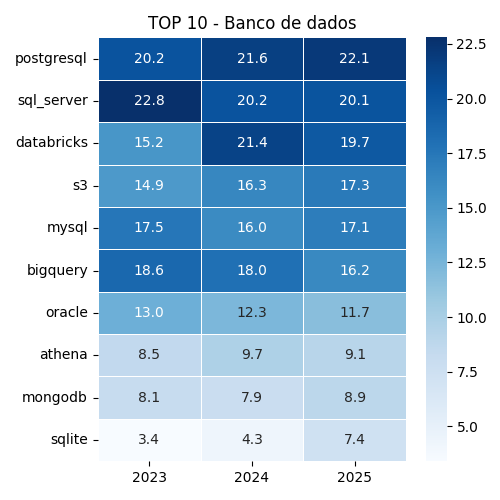

In [22]:
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("banco_de_dados")
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False).head(10) # Top 10

plt.figure(figsize=(5, 5))

sns.heatmap(
    df_pandas_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5
)

plt.title("TOP 10 - Banco de dados")
plt.xlabel("")
plt.ylabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
%matplot plt

### Cloud

In [23]:
cloud_long = tb_stack_tecnologico.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(7,
        'azure', cloud_trabalhadas_azure_microsoft,
        'aws', cloud_trabalhadas_amazon_web_services_aws,
        'gcp', cloud_trabalhadas_google_cloud_gcp,
        'oracle', cloud_trabalhadas_oracle_cloud,
        'ibm', cloud_trabalhadas_ibm,
        'servidores_on_premisse', cloud_trabalhadas_servidores_on_premise,
        'cloud_propria', cloud_trabalhadas_cloud_propria
    ) as (cloud, trabalhada)"""
)

# 2. Total de respondentes por ano (base confiável: tb_pessoa)
total_por_ano = tb_pessoa.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# 3. Contagem de "true" por fonte de dado e ano
contagem_true = cloud_long.filter(F.col("trabalhada") == True) \
    .groupBy("cloud", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# 4. Join para calcular o percentual
resultado_pct = contagem_true.join(total_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

# 5. Pivotar para visualização (fonte de dado x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("cloud") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

                    cloud  2023  2024  2025
0           cloud_propria   4.7   3.7   3.3
1                     gcp  21.6  20.1  18.5
2                     aws  20.9  30.4  28.9
3                  oracle   2.9   2.7   2.7
4  servidores_on_premisse  11.0   8.9   8.6
5                   azure  28.9  21.2  20.9
6                     ibm   0.9   1.1   0.7


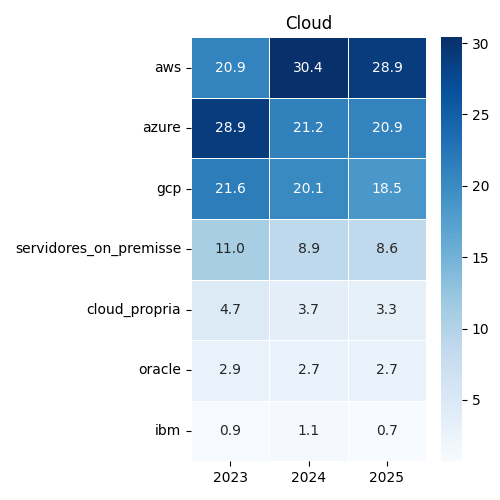

In [24]:
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("cloud")
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False)

plt.figure(figsize=(5, 5))

sns.heatmap(
    df_pandas_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5
)

plt.title("Cloud")
plt.ylabel("")
plt.xlabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
%matplot plt

### Linguagem de Programação

In [26]:
# Total de respondentes por ano (base confiável: tb_pessoa)
total_por_ano = tb_pessoa.groupBy("ano_pesquisa").agg(
    F.countDistinct("token").alias("total_respondentes")
)

# --- 1. Processamento: Linguagem Trabalhada (2023 e 2024) ---
long_trab = (
    tb_stack_tecnologico.filter(F.col("ano_pesquisa").isin([2023, 2024]))
    .selectExpr(
        "ano_pesquisa",
        "token",
        """stack(15,
        'sql', linguagens_programacao_trabalhadas_sql,
        'r', linguagens_programacao_trabalhadas_r,
        'python', linguagens_programacao_trabalhadas_python,
        'c/c++/c#', `linguagens_programacao_trabalhadas_c_c++_c#`,
        '.net', linguagens_programacao_trabalhadas_dotnet,
        'java', linguagens_programacao_trabalhadas_java,
        'julia', linguagens_programacao_trabalhadas_julia,
        'sas_stata', linguagens_programacao_trabalhadas_sas_stata,
        'vba', linguagens_programacao_trabalhadas_visual_basic_vba,
        'scala', linguagens_programacao_trabalhadas_scala,
        'matlab', linguagens_programacao_trabalhadas_matlab,
        'rust', linguagens_programacao_trabalhadas_rust,
        'php', linguagens_programacao_trabalhadas_php,
        'javascript', linguagens_programacao_trabalhadas_javascript,
        'Não Utilizo as listadas', linguagens_programacao_trabalhadas_nao_utilizo_linguagens_listadas
    ) as (linguagem, resp)""",
    )
)

pct_trab = (
    long_trab.filter(F.col("resp") == True)
    .groupBy("linguagem", "ano_pesquisa")
    .agg(F.count("token").alias("qtd_true"))
    .join(total_por_ano, on="ano_pesquisa", how="left")
    .withColumn(
        "percentual",
        F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1),
    )
    .withColumn(
        "tipo_pergunta", F.lit("Trabalhada (Uso)")
    )  # Identificador da pergunta
    .select("linguagem", "ano_pesquisa", "percentual", "tipo_pergunta")
)

# --- 2. Processamento: Linguagem Preferida (2025) ---
long_pref = (
    tb_stack_tecnologico.filter(F.col("ano_pesquisa") == 2025)
    .selectExpr(
        "ano_pesquisa",
        "token",
        """stack(10,
        'sql', linguagem_preferida_sql,
        'r', linguagem_preferida_r,
        'python', linguagem_preferida_python,
        'c/c++/c#', `linguagem_preferida_c_c++_c#`,
        'julia', linguagem_preferida_julia,
        'vba', linguagem_preferida_visual_basic_vba,
        'scala', linguagem_preferida_scala,
        'dax', linguagem_preferida_dax,
        'rust', linguagem_preferida_rust,
        'Não Utilizo as listadas', linguagem_preferida_nao_utilizo_linguagens_listadas
    ) as (linguagem, resp)""",
    )
)

pct_pref = (
    long_pref.filter(F.col("resp") == True)
    .groupBy("linguagem", "ano_pesquisa")
    .agg(F.count("token").alias("qtd_true"))
    .join(total_por_ano, on="ano_pesquisa", how="left")
    .withColumn(
        "percentual",
        F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1),
    )
    .withColumn(
        "tipo_pergunta", F.lit("Preferida")
    )  # Identificador da pergunta
    .select("linguagem", "ano_pesquisa", "percentual", "tipo_pergunta")
)

# --- 3. União dos Resultados ---
resultado_unificado = pct_trab.union(pct_pref)

# 4. Pivotar para visualização final (Linguagem x Ano)
resultado_pivot_pct = (
    resultado_unificado.groupBy("linguagem", "tipo_pergunta")
    .pivot("ano_pesquisa", [2023, 2024, 2025])
    .agg(F.first("percentual"))
)

# Converter para Pandas
df_final = resultado_pivot_pct.toPandas()
df_final

                  linguagem     tipo_pergunta  2023  2024  2025
0                 sas_stata  Trabalhada (Uso)   2.9   2.5   NaN
1                      rust  Trabalhada (Uso)   0.1   0.2   NaN
2                     julia         Preferida   NaN   NaN   0.5
3                    python  Trabalhada (Uso)  53.4  56.3   NaN
4                       php  Trabalhada (Uso)   1.1   0.7   NaN
5                       vba  Trabalhada (Uso)   5.4   4.1   NaN
6                     scala  Trabalhada (Uso)   2.5   2.4   NaN
7   Não Utilizo as listadas  Trabalhada (Uso)   5.8   NaN   NaN
8                      java  Trabalhada (Uso)   6.7   5.6   NaN
9                      .net  Trabalhada (Uso)   0.8   0.6   NaN
10                   python         Preferida   NaN   NaN  55.2
11                      sql         Preferida   NaN   NaN  50.5
12                        r         Preferida   NaN   NaN   9.4
13                      dax         Preferida   NaN   NaN   0.2
14               javascript  Trabalhada 

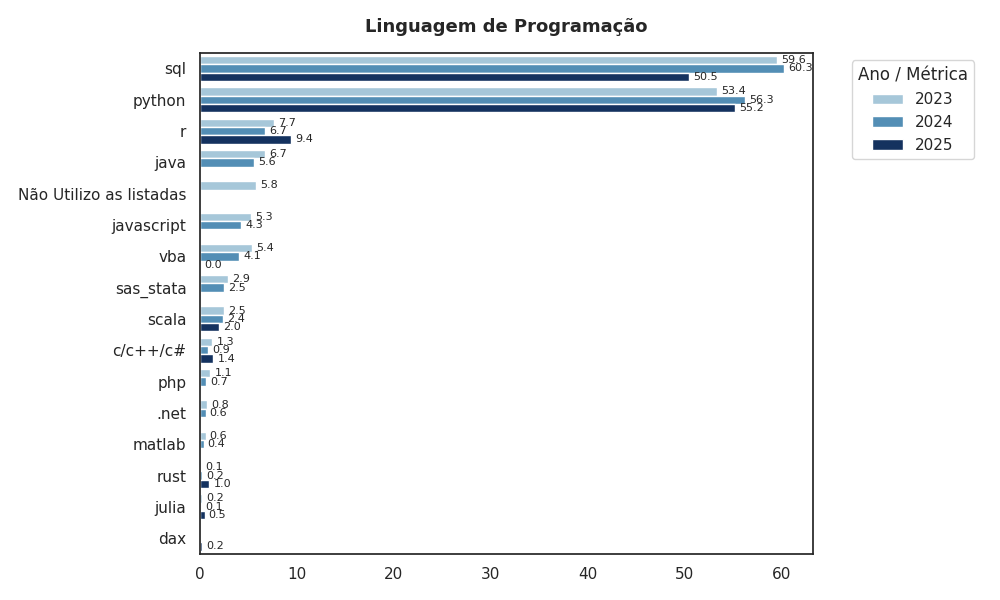

In [27]:
# 0. Converter o resultado do PySpark para Pandas (Garante que a variável existe)
df_plot = resultado_unificado.toPandas()

# 1. Ordena do maior para o menor (o primeiro da lista fica no topo do gráfico)
ordem_linguagens = (
    df_plot.groupby("linguagem")["percentual"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

# 2. Paleta de azuis ajustada para legibilidade ([2023, 2024, 2025])
cores_azuis_visiveis = [
    "#9ecae1",
    "#4292c6",
    "#08306b",
]

ax = sns.barplot(
    data=df_plot,
    y="linguagem",
    x="percentual",
    hue="ano_pesquisa",
    order=ordem_linguagens,
    palette=cores_azuis_visiveis,
)

# 3. Adicionar os rótulos de dados em cada barra
for container in ax.containers:
  ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

# 4. Ajustes visuais
plt.title(
    "Linguagem de Programação",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("", fontsize=11)
plt.ylabel("", fontsize=11)
plt.legend(title="Ano / Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
%matplot plt

### Ferramenta Bi


In [28]:
# 1. Despivotar as colunas de ferramentas de BI (wide -> long)
ferramentas_bi_long = tb_stack_tecnologico.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(23,
        'power_bi', ferramentas_bi_trabalhadas_microsoft_powerbi,
        'qlik_view_sense', ferramentas_bi_trabalhadas_qlik_view_qlik_sense,
        'tableau', ferramentas_bi_trabalhadas_tableau,
        'metabase', ferramentas_bi_trabalhadas_metabase,
        'superset', ferramentas_bi_trabalhadas_superset,
        'redash', ferramentas_bi_trabalhadas_redash,
        'looker', ferramentas_bi_trabalhadas_looker,
        'looker_studio', ferramentas_bi_trabalhadas_looker_studio_google_data_studio,
        'quicksight', ferramentas_bi_trabalhadas_amazon_quicksight,
        'mode', ferramentas_bi_trabalhadas_mode,
        'alteryx', ferramentas_bi_trabalhadas_alteryx,
        'microstrategy', ferramentas_bi_trabalhadas_microstrategy,
        'ibm_cognos', ferramentas_bi_trabalhadas_ibm_analytics_cognos,
        'sap_business_objects', ferramentas_bi_trabalhadas_sap_business_objects_sap_analytics,
        'oracle_bi', ferramentas_bi_trabalhadas_oracle_business_intelligence,
        'salesforce_einstein', ferramentas_bi_trabalhadas_salesforce_einstein_analytics,
        'birst', ferramentas_bi_trabalhadas_birst,
        'sas_visual_analytics', ferramentas_bi_trabalhadas_sas_visual_analytics,
        'grafana', ferramentas_bi_trabalhadas_grafana,
        'tibco_spotfire', ferramentas_bi_trabalhadas_tibco_spotfire,
        'pentaho', ferramentas_bi_trabalhadas_pentaho,
        'excel_planilhas_google', ferramentas_bi_trabalhadas_fazemos_as_analises_utilizando_excel_planilhas_google,
        'nao_utilizo_bi', ferramentas_bi_trabalhadas_nao_utilizo_bi
    ) as (ferramenta_bi, trabalhada)"""
)

# 2. Total de respondentes por ano (base confiável: tb_pessoa)
total_por_ano = tb_pessoa.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# 3. Contagem de "true" por ferramenta de BI e ano
contagem_true = ferramentas_bi_long.filter(F.col("trabalhada") == True) \
    .groupBy("ferramenta_bi", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# 4. Join para calcular o percentual
resultado_pct = contagem_true.join(total_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

# 5. Pivotar para visualização (ferramenta de BI x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("ferramenta_bi") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

             ferramenta_bi  2023  2024  2025
0                   looker  17.0  15.9  13.6
1            microstrategy   0.7   NaN   NaN
2                 power_bi  40.7  38.3  35.5
3     sap_business_objects   1.5   1.1   1.5
4               quicksight   2.6   3.2   4.1
5                   redash   1.2   1.1   0.4
6               ibm_cognos   0.5   NaN   NaN
7                    birst   0.1   NaN   NaN
8                 metabase   6.1   6.1   5.1
9          qlik_view_sense   3.7   3.4   2.6
10           looker_studio  12.3  11.6   9.4
11    sas_visual_analytics   1.6   1.4   1.0
12                 grafana   5.2   5.6   5.2
13                 alteryx   1.9   1.4   1.2
14                 pentaho   3.3   2.2   1.9
15                superset   1.6   1.9   1.9
16               oracle_bi   0.9   0.7   0.5
17     salesforce_einstein   1.6   1.8   1.2
18  excel_planilhas_google   7.4   7.4   6.2
19          nao_utilizo_bi   7.7   6.8   6.8
20                 tableau  13.5  13.2   8.2
21        

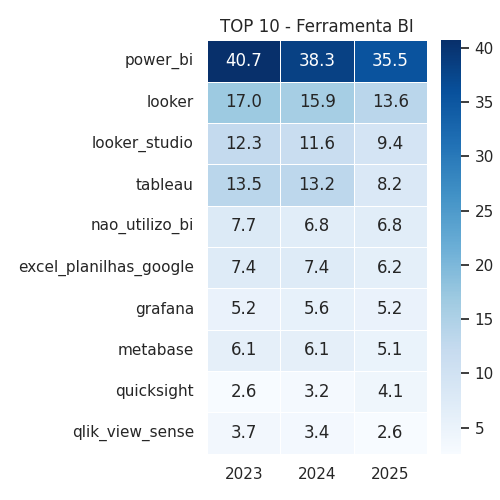

In [29]:
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("ferramenta_bi")
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False).head(10)

plt.figure(figsize=(5, 5))

sns.heatmap(
    df_pandas_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5
)

plt.title("TOP 10 - Ferramenta BI")
plt.ylabel("")
plt.xlabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
%matplot plt

## Qual é o índice de adoção de Inteligência Artificial e seu impacto?


In [30]:
# 1. Despivotar as 5 colunas "guarda-chuva" (wide -> long)
ia_long = tb_ia.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(5,
        'Não Utilizo', usa_chatgpt_copilot_trabalho_nao_uso_ia_para_produtividade,
        'Versão gratuita para produtividade', usa_chatgpt_copilot_trabalho_uso_ia_gratuita_para_produtividade,
        'Pago premium para produtividadde', usa_chatgpt_copilot_trabalho_uso_e_pago_ia_para_produtividade,
        'A empresa paga premium para produtividade', usa_chatgpt_copilot_trabalho_empr_atual_paga_ia_para_produtividade,
        'uso soluções do tipo Copilot', usa_chatgpt_copilot_trabalho_uso_solucoes_do_tipo_copilot
    ) as (respostas, valor)"""
)

# 2. Total de respondentes por ano (base confiável: tb_pessoa)
total_por_ano = tb_pessoa.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

# 3. Contagem de "true" por fonte de dado e ano
contagem_true = ia_long.filter(F.col("valor") == True) \
    .groupBy("respostas", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

# 4. Join para calcular o percentual de adoção/resposta
resultado_pct = contagem_true.join(total_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

# 5. Pivotar para visualização (vertical x ano, em %)
resultado_pivot_pct = resultado_pct.groupBy("respostas") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]) \
    .agg(F.first("percentual"))

resultado_pivot_pct.toPandas()

                                   respostas  2023  2024  2025
0         Versão gratuita para produtividade  45.4  37.3  18.4
1  A empresa paga premium para produtividade   4.5  13.4  25.5
2           Pago premium para produtividadde   4.9  10.8  16.2
3                                Não Utilizo  14.1   4.5   1.3
4               uso soluções do tipo Copilot   8.4  16.5  18.0


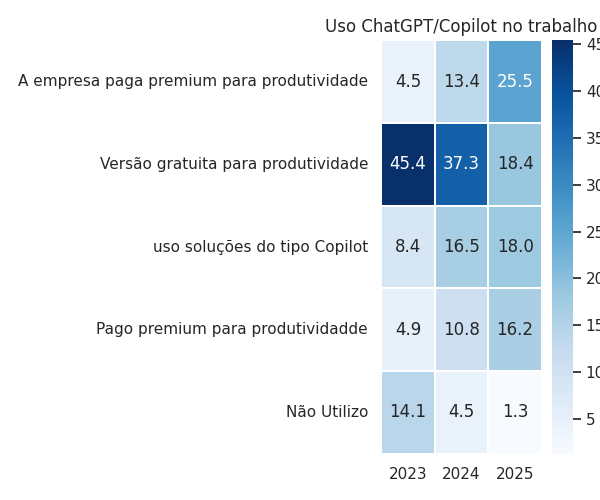

In [58]:
df_pandas_pct = resultado_pivot_pct.toPandas().set_index("respostas")
df_pandas_pct = df_pandas_pct.sort_values(by="2025", ascending=False)

plt.figure(figsize=(6, 5))

sns.heatmap(
    df_pandas_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=True,
    linewidths=0.2
)

plt.title("Uso ChatGPT/Copilot no trabalho")
plt.ylabel("")
plt.xlabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
%matplot plt

In [35]:
tb_ia.groupby("empresa_esta_conseguindo_ter_bons_resultados_com_llms").pivot("ano_pesquisa").count().show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------+----+----+----+
|empresa_esta_conseguindo_ter_bons_resultados_com_llms                                                                                     |2023|2024|2025|
+------------------------------------------------------------------------------------------------------------------------------------------+----+----+----+
|                                                                                                                                          |NULL|NULL|2848|
|Não sei opinar sobre isso.                                                                                                                |NULL|NULL|43  |
|Não. Os projetos envolvendo AI Generativa e Modelos LLM, ainda estão em fase de investigação e planejamento.                              |NULL|NULL|97  |
|Não, ainda não começamos nenhum projeto envolvendo AI Generativ

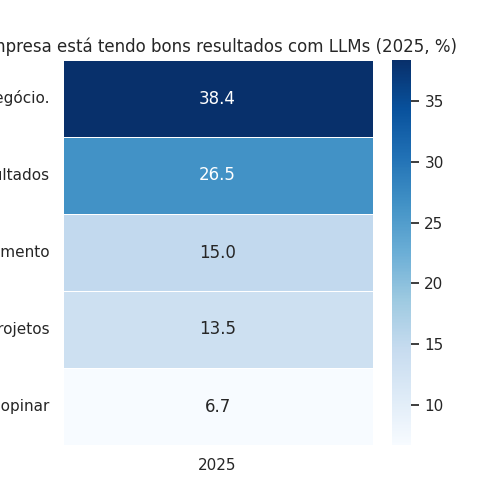

In [38]:
tb_resultados_llm_valido = tb_ia.filter(
    F.col("empresa_esta_conseguindo_ter_bons_resultados_com_llms").isNotNull() &
    (F.trim(F.col("empresa_esta_conseguindo_ter_bons_resultados_com_llms")) != "") &
    (F.col("ano_pesquisa") == 2025)
)

total_2025 = tb_resultados_llm_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

contagem_resultados_llm = tb_resultados_llm_valido.groupBy(
    "empresa_esta_conseguindo_ter_bons_resultados_com_llms", "ano_pesquisa"
).agg(F.count("token").alias("qtd"))

resultado_pct_llm = contagem_resultados_llm.join(total_2025, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_respondentes") * 100, 1))

pivot_resultados_llm = resultado_pct_llm.groupBy("empresa_esta_conseguindo_ter_bons_resultados_com_llms") \
    .pivot("ano_pesquisa", [2025]).agg(F.first("percentual"))

df_resultados_llm = pivot_resultados_llm.toPandas() \
    .set_index("empresa_esta_conseguindo_ter_bons_resultados_com_llms") \
    .sort_values(by="2025", ascending=False)

# Agora sim, o mapeamento de rótulos — depois que df_resultados_llm já existe
mapa_labels_llm = {
    "Sim. Temos projetos envolvendo AI Generativa e Modelos LLM em produção, gerando resultados e impacto no negócio.": "Sim, com resultados",
    "Em partes. Temos alguns projetos \"piloto\"": "Parcialmente (projetos piloto)",
    "Não. Os projetos envolvendo AI Generativa e Modelos LLM, ainda estão em fase de investigação e planejamento.": "Não, em planejamento",
    "Não, ainda não começamos nenhum projeto envolvendo AI Generativa e Modelos LLM.": "Não iniciamos projetos",
    "Não sei opinar sobre isso.": "Não sei opinar",
}
df_resultados_llm.index = df_resultados_llm.index.map(lambda x: mapa_labels_llm.get(x, x))

plt.figure(figsize=(5, 5))
sns.heatmap(df_resultados_llm, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, cbar=True)
plt.title("Empresa está tendo bons resultados com LLMs (2025, %)")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()
%matplot plt

## Quais oportunidades e desafios podem ser identificados para empresas que desejam investir em Dados e Inteligência Artificial?

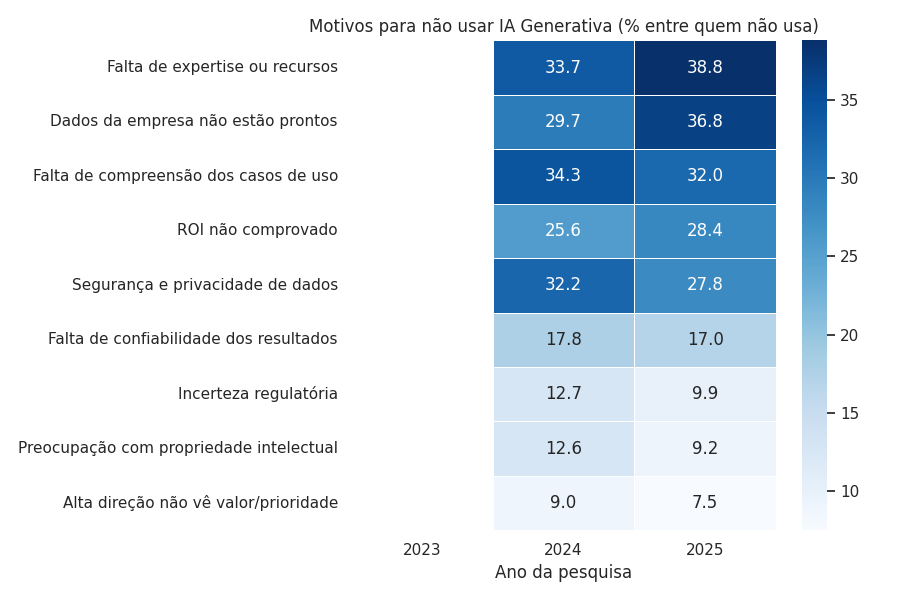

In [41]:
tb_ia_nao_usa = tb_ia.filter(
    (F.col("motivos_nao_usar_ai_generativa_e_llm").isNotNull()) &
    (F.trim(F.col("motivos_nao_usar_ai_generativa_e_llm")) != "")
)

motivos_long = tb_ia_nao_usa.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(9,
        'Falta de compreensão dos casos de uso', motivos_nao_usar_ai_generativa_e_llm_falta_de_compreensao_uso,
        'Falta de confiabilidade dos resultados', motivos_nao_usar_ai_generativa_e_llm_falta_de_confiabilidade_resultado,
        'Incerteza regulatória', motivos_nao_usar_ai_generativa_e_llm_incerteza_regulamentacao,
        'Segurança e privacidade de dados', motivos_nao_usar_ai_generativa_e_llm_seg_priv_de_dados,
        'ROI não comprovado', motivos_nao_usar_ai_generativa_e_llm_roi_nao_comprovado,
        'Dados da empresa não estão prontos', motivos_nao_usar_ai_generativa_e_llm_dados_da_empresa_nao_estao_prontos,
        'Falta de expertise ou recursos', motivos_nao_usar_ai_generativa_e_llm_falta_de_expertise_recursos,
        'Alta direção não vê valor/prioridade', motivos_nao_usar_ai_generativa_e_llm_alta_direcao_nao_ve_valor_prioridade,
        'Preocupação com propriedade intelectual', motivos_nao_usar_ai_generativa_e_llm_preocupacao_prop_intelectual
    ) as (motivo, valor)"""
)

# Novo denominador: só quem respondeu essa pergunta
total_por_ano_nao_usa = tb_ia_nao_usa.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

contagem_motivos = motivos_long.filter(F.col("valor") == True) \
    .groupBy("motivo", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

resultado_pct_motivos = contagem_motivos.join(total_por_ano_nao_usa, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

pivot_motivos = resultado_pct_motivos.groupBy("motivo") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

df_motivos = pivot_motivos.toPandas().set_index("motivo").sort_values(by="2025", ascending=False)

plt.figure(figsize=(9, 6))
sns.heatmap(df_motivos, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Motivos para não usar IA Generativa (% entre quem não usa)")
plt.ylabel("")
plt.xlabel("Ano da pesquisa")
plt.tight_layout()
plt.show()
%matplot plt

In [42]:
# Filtra apenas quem é gestor
tb_gestor_valido = tb_pessoa.filter(F.col("atua_como_gestor") == True)

desafios_long = tb_rotina_profissional.join(
    tb_gestor_valido.select("token", "ano_pesquisa"),
    on=["token", "ano_pesquisa"],
    how="inner"
).selectExpr(
    "ano_pesquisa",
    "token",
    """stack(14,
        'Contratar talentos', desaf_como_gestor_contratar_talentos,
        'Reter talentos', desaf_como_gestor_reter_talentos,
        'Aumentar investimentos em dados', desaf_como_gestor_aumentar_investimentos_dados,
        'Gestão de equipes remotas', desaf_como_gestor_gestao_de_equipes_no_trab_remoto,
        'Gestão de projetos multidisciplinares', desaf_como_gestor_gestao_de_projetos_multidisciplinares,
        'Qualidade e confiabilidade da informação', desaf_como_gestor_organizar_info_com_qualidade_confiabilidade,
        'Processar/armazenar alto volume de dados', desaf_como_gestor_processar_armazenar_alto_vol_dados,
        'Gerar valor para áreas de negócio', desaf_como_gestor_gerar_valor_para_areas_de_neg,
        'Desenvolver/manter modelos ML em produção', desaf_como_gestor_desenvolver_manter_modelos_ml_em_prod,
        'Gerenciar expectativas das áreas', desaf_como_gestor_gerenciar_a_expectativa_das_areas,
        'Manutenção de projetos em produção', desaf_como_gestor_manutencao_projetos_modelos_em_prod,
        'Levar inovação para a empresa', desaf_como_gestor_inovacao,
        'Garantir ROI em projetos de dados', desaf_como_gestor_roi_em_projetos_de_dados,
        'Dividir tempo entre técnico e gestão', desaf_como_gestor_dividir_tempo_entregas_tec_gestao
    ) as (desafio, valor)"""
)

# Total de gestores por ano (novo denominador)
total_gestores_por_ano = tb_gestor_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_gestores"))

contagem_desafios = desafios_long.filter(F.col("valor") == True) \
    .groupBy("desafio", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

resultado_pct_desafios = contagem_desafios.join(total_gestores_por_ano, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_gestores") * 100, 1))

pivot_desafios = resultado_pct_desafios.groupBy("desafio") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

df_desafios = pivot_desafios.toPandas().set_index("desafio").sort_values(by="2025", ascending=False)

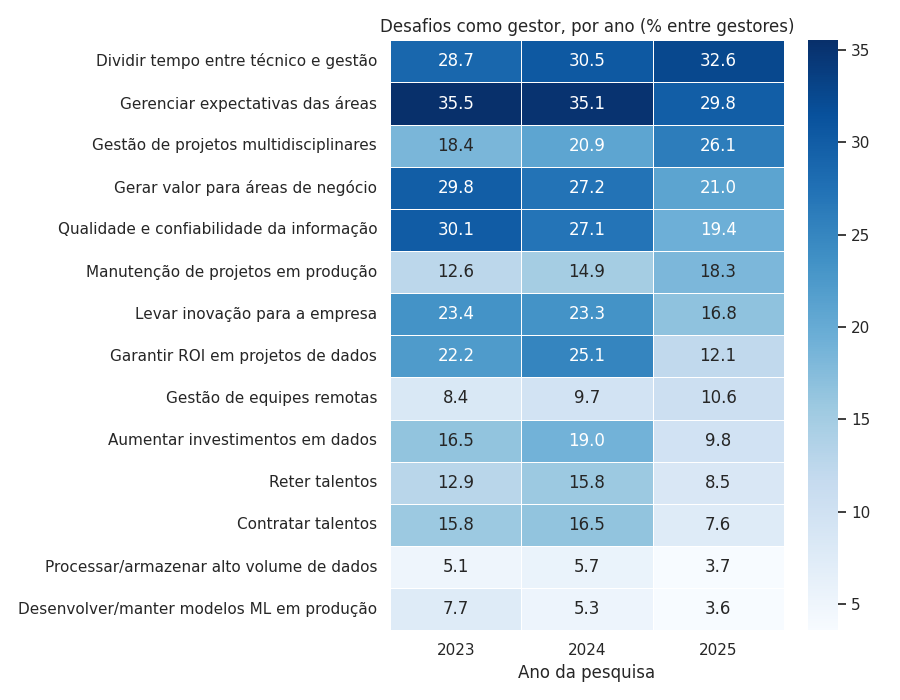

In [43]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_desafios, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Desafios como gestor, por ano (% entre gestores)")
plt.ylabel("")
plt.xlabel("Ano da pesquisa")
plt.tight_layout()
plt.show()
%matplot plt

## Quais perfis profissionais são mais valorizados pelo mercado?

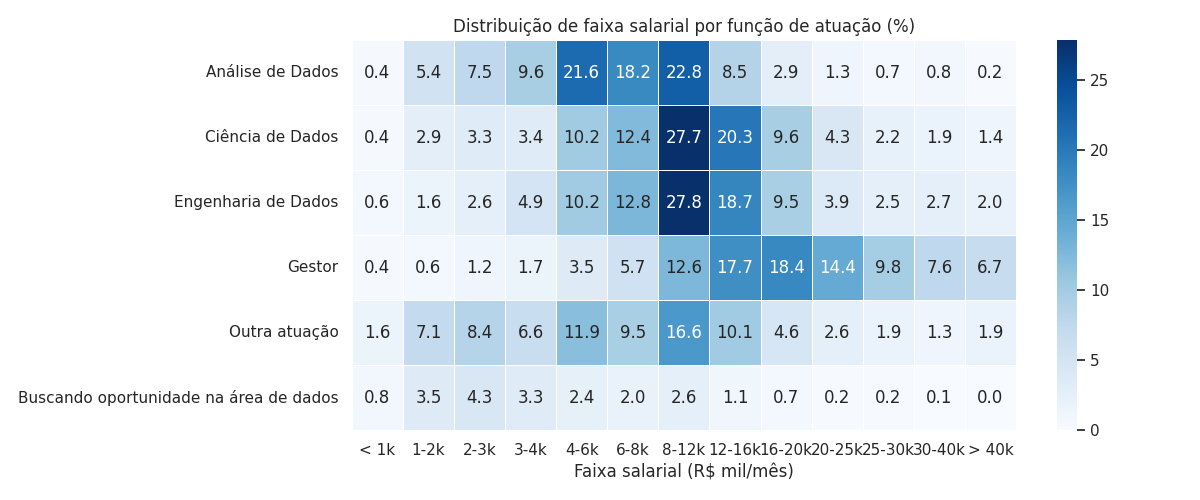

In [44]:
tb_salario_atuacao_valido = tb_pessoa.filter(
    F.col("faixa_salarial").isNotNull() &
    F.col("atuacao_em_dados").isNotNull() &
    (F.col("atuacao_em_dados") != "Vou procurar outra oportunidade no modelo híbrido ou remoto")
)

total_por_atuacao = tb_salario_atuacao_valido.groupBy("atuacao_em_dados") \
    .agg(F.countDistinct("token").alias("total_atuacao"))

contagem_salario_atuacao = tb_salario_atuacao_valido.groupBy("atuacao_em_dados", "faixa_salarial") \
    .agg(F.count("token").alias("qtd"))

resultado_pct_salario_atuacao = contagem_salario_atuacao.join(total_por_atuacao, on="atuacao_em_dados", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_atuacao") * 100, 1))

pivot_salario_atuacao = resultado_pct_salario_atuacao.groupBy("atuacao_em_dados") \
    .pivot("faixa_salarial") \
    .agg(F.first("percentual"))

df_salario_atuacao = pivot_salario_atuacao.toPandas().set_index("atuacao_em_dados").fillna(0)

ordem_faixas = [
    "Menos de R$ 1.000/mês",
    "de R$ 1.001/mês a R$ 2.000/mês",
    "de R$ 2.001/mês a R$ 3.000/mês",
    "de R$ 3.001/mês a R$ 4.000/mês",
    "de R$ 4.001/mês a R$ 6.000/mês",
    "de R$ 6.001/mês a R$ 8.000/mês",
    "de R$ 8.001/mês a R$ 12.000/mês",
    "de R$ 12.001/mês a R$ 16.000/mês",
    "de R$ 16.001/mês a R$ 20.000/mês",
    "de R$ 20.001/mês a R$ 25.000/mês",
    "de R$ 25.001/mês a R$ 30.000/mês",
    "de R$ 30.001/mês a R$ 40.000/mês",
    "Acima de R$ 40.001/mês",
]
df_salario_atuacao = df_salario_atuacao.reindex(columns=ordem_faixas)

mapa_faixas_curto = {
    "Menos de R$ 1.000/mês": "< 1k",
    "de R$ 1.001/mês a R$ 2.000/mês": "1-2k",
    "de R$ 2.001/mês a R$ 3.000/mês": "2-3k",
    "de R$ 3.001/mês a R$ 4.000/mês": "3-4k",
    "de R$ 4.001/mês a R$ 6.000/mês": "4-6k",
    "de R$ 6.001/mês a R$ 8.000/mês": "6-8k",
    "de R$ 8.001/mês a R$ 12.000/mês": "8-12k",
    "de R$ 12.001/mês a R$ 16.000/mês": "12-16k",
    "de R$ 16.001/mês a R$ 20.000/mês": "16-20k",
    "de R$ 20.001/mês a R$ 25.000/mês": "20-25k",
    "de R$ 25.001/mês a R$ 30.000/mês": "25-30k",
    "de R$ 30.001/mês a R$ 40.000/mês": "30-40k",
    "Acima de R$ 40.001/mês": "> 40k",
}
df_salario_atuacao = df_salario_atuacao.rename(columns=mapa_faixas_curto)

ordem_atuacao = [
    "Análise de Dados",
    "Ciência de Dados",
    "Engenharia de Dados",
    "Gestor",
    "Outra atuação",
    "Buscando oportunidade na área de dados",
]
df_salario_atuacao = df_salario_atuacao.reindex(ordem_atuacao)

plt.figure(figsize=(12, 5))
sns.heatmap(df_salario_atuacao, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição de faixa salarial por função de atuação (%)")
plt.ylabel("")
plt.xlabel("Faixa salarial (R$ mil/mês)")
plt.tight_layout()
plt.show()
%matplot plt

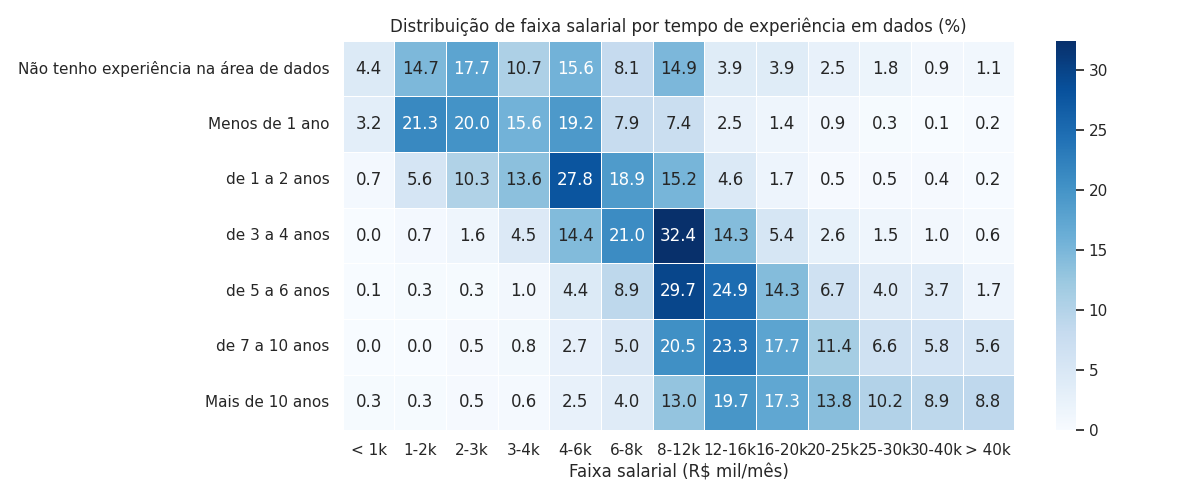

In [45]:
tb_salario_exp_valido = tb_pessoa.filter(
    F.col("faixa_salarial").isNotNull() &
    F.col("tempo_de_experiencia_em_dados").isNotNull()
)

total_por_exp = tb_salario_exp_valido.groupBy("tempo_de_experiencia_em_dados") \
    .agg(F.countDistinct("token").alias("total_exp"))

contagem_salario_exp = tb_salario_exp_valido.groupBy("tempo_de_experiencia_em_dados", "faixa_salarial") \
    .agg(F.count("token").alias("qtd"))

resultado_pct_salario_exp = contagem_salario_exp.join(total_por_exp, on="tempo_de_experiencia_em_dados", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_exp") * 100, 1))

pivot_salario_exp = resultado_pct_salario_exp.groupBy("tempo_de_experiencia_em_dados") \
    .pivot("faixa_salarial") \
    .agg(F.first("percentual"))

df_salario_exp = pivot_salario_exp.toPandas().set_index("tempo_de_experiencia_em_dados").fillna(0)

ordem_experiencia = [
    "Não tenho experiência na área de dados",
    "Menos de 1 ano",
    "de 1 a 2 anos",
    "de 3 a 4 anos",
    "de 5 a 6 anos",
    "de 7 a 10 anos",
    "Mais de 10 anos",
]
df_salario_exp = df_salario_exp.reindex(ordem_experiencia)
df_salario_exp = df_salario_exp.reindex(columns=ordem_faixas).rename(columns=mapa_faixas_curto)

plt.figure(figsize=(12, 5))
sns.heatmap(df_salario_exp, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição de faixa salarial por tempo de experiência em dados (%)")
plt.ylabel("")
plt.xlabel("Faixa salarial (R$ mil/mês)")
plt.tight_layout()
plt.show()
%matplot plt

## Como está estruturado o mercado brasileiro de Dados?

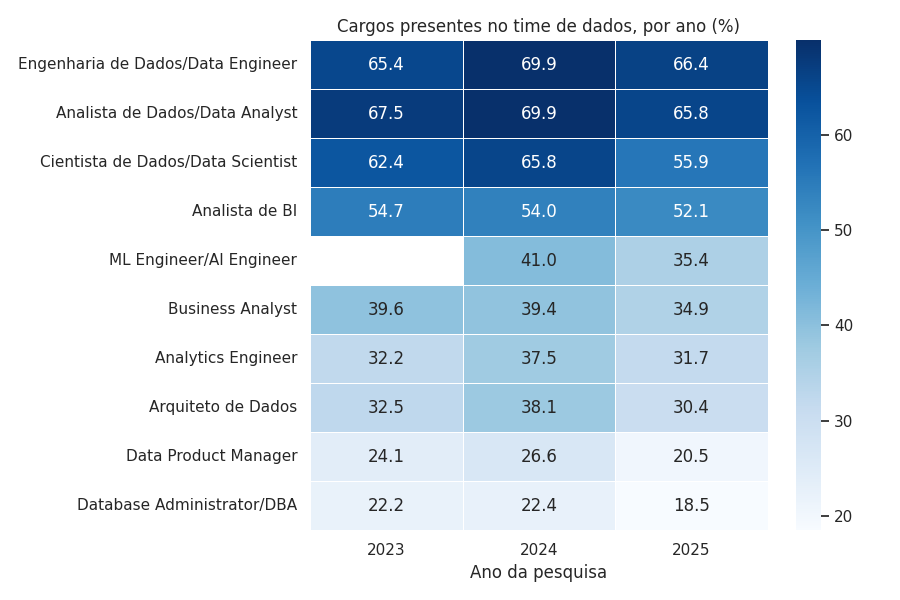

In [47]:
cargos_long = tb_empresa_atual.selectExpr(
    "ano_pesquisa",
    "token",
    """stack(10,
        'Analytics Engineer', cargos_time_dados_empr_atual_analytics_engineer,
        'Engenharia de Dados/Data Engineer', cargos_time_dados_empr_atual_engenharia_de_dados_data_engineer,
        'Analista de Dados/Data Analyst', cargos_time_dados_empr_atual_analista_de_dados_data_analyst,
        'Cientista de Dados/Data Scientist', cargos_time_dados_empr_atual_cientista_de_dados_data_scientist,
        'Database Administrator/DBA', cargos_time_dados_empr_atual_database_administrator_dba,
        'Analista de BI', cargos_time_dados_empr_atual_analista_de_business_intelligence_bi,
        'Arquiteto de Dados', cargos_time_dados_empr_atual_arquiteto_de_dados_data_architect,
        'Data Product Manager', cargos_time_dados_empr_atual_data_product_manager_dpm,
        'Business Analyst', cargos_time_dados_empr_atual_business_analyst,
        'ML Engineer/AI Engineer', cargos_time_dados_empr_atual_ml_engineer_ai_engineer
    ) as (cargo, valor)"""
)

tb_empresa_valido = tb_empresa_atual.filter(
    (F.col("cargos_time_dados_empr_atual").isNotNull()) &
    (F.trim(F.col("cargos_time_dados_empr_atual")) != "")
)
total_por_ano_empresa = tb_empresa_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

contagem_cargos = cargos_long.filter(F.col("valor") == True) \
    .groupBy("cargo", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd_true"))

resultado_pct_cargos = contagem_cargos.join(total_por_ano_empresa, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd_true") / F.col("total_respondentes") * 100, 1))

pivot_cargos = resultado_pct_cargos.groupBy("cargo") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

df_cargos = pivot_cargos.toPandas().set_index("cargo").sort_values(by="2025", ascending=False)

plt.figure(figsize=(9, 6))
sns.heatmap(df_cargos, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Cargos presentes no time de dados, por ano (%)")
plt.ylabel("")
plt.xlabel("Ano da pesquisa")
plt.tight_layout()
plt.show()
%matplot plt

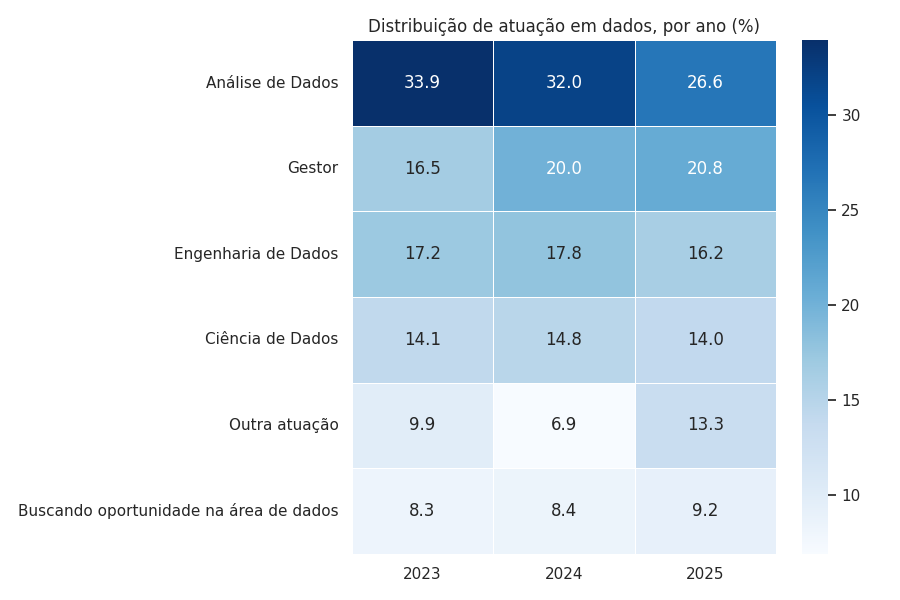

In [48]:
tb_atuacao_valido = tb_pessoa.filter(
    F.col("atuacao_em_dados").isNotNull() &
    (F.col("atuacao_em_dados") != "Vou procurar outra oportunidade no modelo híbrido ou remoto")
)

total_por_ano_atuacao = tb_atuacao_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

contagem_atuacao = tb_atuacao_valido.groupBy("atuacao_em_dados", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd"))

resultado_pct_atuacao = contagem_atuacao.join(total_por_ano_atuacao, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_respondentes") * 100, 1))

pivot_atuacao = resultado_pct_atuacao.groupBy("atuacao_em_dados") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

df_atuacao = pivot_atuacao.toPandas().set_index("atuacao_em_dados").sort_values(by="2025", ascending=False)

plt.figure(figsize=(9, 6))
sns.heatmap(df_atuacao, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição de atuação em dados, por ano (%)")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()
%matplot plt

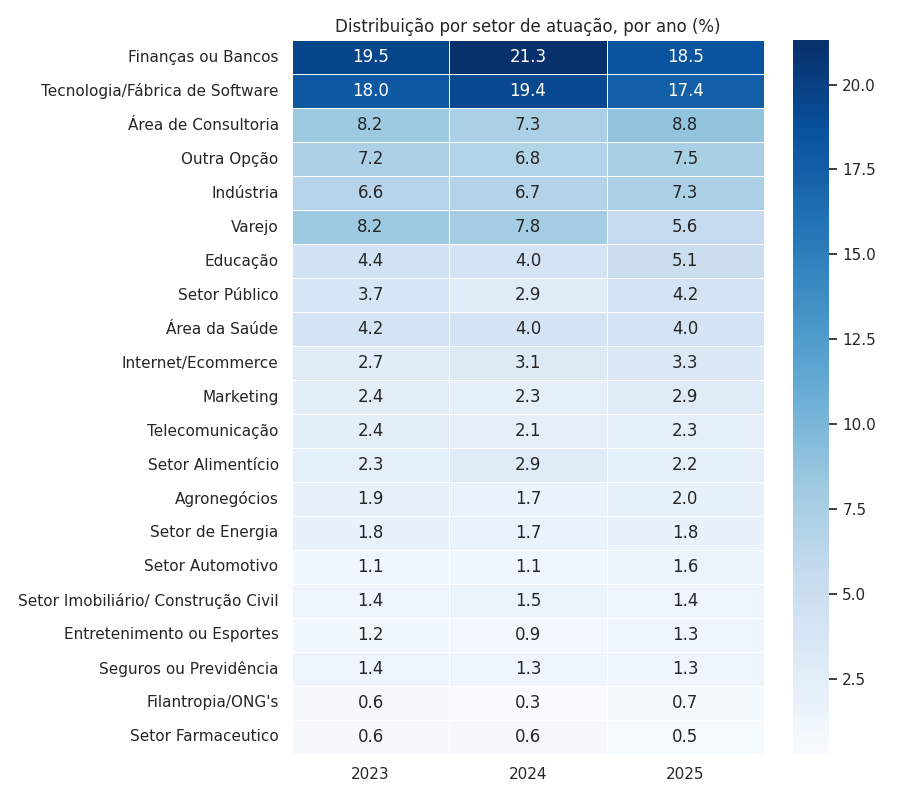

In [50]:
tb_setor_valido = tb_pessoa.filter(
    (F.col("setor").isNotNull()) &
    (F.trim(F.col("setor")) != "")
)

total_por_ano_setor = tb_setor_valido.groupBy("ano_pesquisa") \
    .agg(F.countDistinct("token").alias("total_respondentes"))

contagem_setor = tb_setor_valido.groupBy("setor", "ano_pesquisa") \
    .agg(F.count("token").alias("qtd"))

resultado_pct_setor = contagem_setor.join(total_por_ano_setor, on="ano_pesquisa", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_respondentes") * 100, 1))

pivot_setor = resultado_pct_setor.groupBy("setor") \
    .pivot("ano_pesquisa", [2023, 2024, 2025]).agg(F.first("percentual"))

df_setor = pivot_setor.toPandas().set_index("setor").sort_values(by="2025", ascending=False)

plt.figure(figsize=(9, 8))
sns.heatmap(df_setor, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição por setor de atuação, por ano (%)")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()
%matplot plt

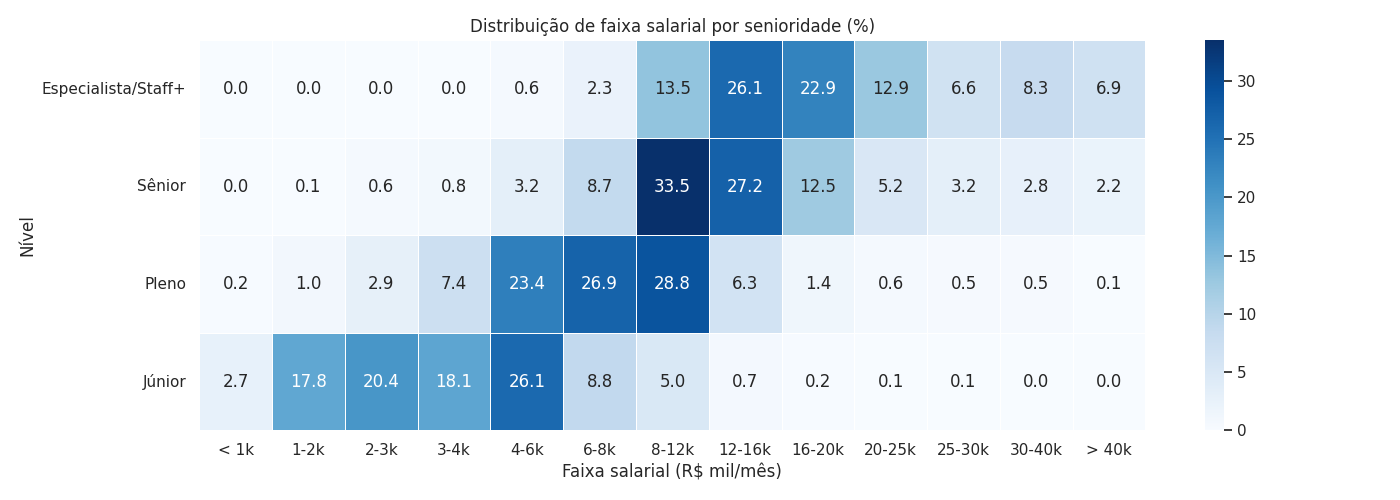

In [51]:
tb_salario_nivel_valido = tb_pessoa.filter(
    F.col("faixa_salarial").isNotNull() &
    F.col("nivel").isNotNull()
)

total_por_nivel = tb_salario_nivel_valido.groupBy("nivel") \
    .agg(F.countDistinct("token").alias("total_nivel"))

contagem_salario_nivel = tb_salario_nivel_valido.groupBy("nivel", "faixa_salarial") \
    .agg(F.count("token").alias("qtd"))

resultado_pct_salario = contagem_salario_nivel.join(total_por_nivel, on="nivel", how="left") \
    .withColumn("percentual", F.round(F.col("qtd") / F.col("total_nivel") * 100, 1))

pivot_salario = resultado_pct_salario.groupBy("nivel") \
    .pivot("faixa_salarial") \
    .agg(F.first("percentual"))

df_salario = pivot_salario.toPandas().set_index("nivel").fillna(0)

ordem_senioridade = ["Especialista/Staff+", "Sênior", "Pleno", "Júnior"]
df_salario = df_salario.reindex(ordem_senioridade)

ordem_faixas = [
    "Menos de R$ 1.000/mês",
    "de R$ 1.001/mês a R$ 2.000/mês",
    "de R$ 2.001/mês a R$ 3.000/mês",
    "de R$ 3.001/mês a R$ 4.000/mês",
    "de R$ 4.001/mês a R$ 6.000/mês",
    "de R$ 6.001/mês a R$ 8.000/mês",
    "de R$ 8.001/mês a R$ 12.000/mês",
    "de R$ 12.001/mês a R$ 16.000/mês",
    "de R$ 16.001/mês a R$ 20.000/mês",
    "de R$ 20.001/mês a R$ 25.000/mês",
    "de R$ 25.001/mês a R$ 30.000/mês",
    "de R$ 30.001/mês a R$ 40.000/mês",
    "Acima de R$ 40.001/mês",
]
df_salario = df_salario.reindex(columns=ordem_faixas)

# Rótulos curtos para o eixo X
mapa_faixas_curto = {
    "Menos de R$ 1.000/mês": "< 1k",
    "de R$ 1.001/mês a R$ 2.000/mês": "1-2k",
    "de R$ 2.001/mês a R$ 3.000/mês": "2-3k",
    "de R$ 3.001/mês a R$ 4.000/mês": "3-4k",
    "de R$ 4.001/mês a R$ 6.000/mês": "4-6k",
    "de R$ 6.001/mês a R$ 8.000/mês": "6-8k",
    "de R$ 8.001/mês a R$ 12.000/mês": "8-12k",
    "de R$ 12.001/mês a R$ 16.000/mês": "12-16k",
    "de R$ 16.001/mês a R$ 20.000/mês": "16-20k",
    "de R$ 20.001/mês a R$ 25.000/mês": "20-25k",
    "de R$ 25.001/mês a R$ 30.000/mês": "25-30k",
    "de R$ 30.001/mês a R$ 40.000/mês": "30-40k",
    "Acima de R$ 40.001/mês": "> 40k",
}
df_salario = df_salario.rename(columns=mapa_faixas_curto)

plt.figure(figsize=(14, 5))
sns.heatmap(df_salario, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Distribuição de faixa salarial por senioridade (%)")
plt.ylabel("Nível")
plt.xlabel("Faixa salarial (R$ mil/mês)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
%matplot plt

## Encerramento da sessão

In [ ]:
job.commit()